In [1]:
from rcsbapi.search import search_attributes as attrs
# Migration of code rcsbsearchapi to rcsb-api https://github.com/rcsb/py-rcsbsearchapi/issues/51
# https://rcsbapi.readthedocs.io/en/latest/
import os
import requests

In [2]:
ligand_name = 'upadacitinib'

prolog = 'https://pubchem.ncbi.nlm.nih.gov/rest/pug'
url = prolog + '/compound/name/' + ligand_name + '/property/smiles/txt'
res = requests.get(url)
res.status_code

200

In [3]:
os.makedirs('ligands', exist_ok=True)

pH = 7.4
args = '--skip_tautomer'

ligand_smiles = res.text.strip()
ligand_sdf = 'ligands/ligand.sdf'
ligand_pdbqt = 'ligands/ligand.pdbqt'


# Run molscrub to generate protonated 3D SDF
! scrub.py "{ligand_smiles}" -o {ligand_sdf} --ph {pH} {args}

# Convert SDF to PDBQT
! mk_prepare_ligand.py -i {ligand_sdf} -o {ligand_pdbqt}

Scrub completed.
Summary of what happened:
Input molecules supplied: 1
mols processed: 1, skipped by rdkit: 0, failed: 0
nr isomers (tautomers and acid/base conjugates): 1 (avg. 1.000 per mol)
nr conformers:  1 (avg. 1.000 per isomer, 1.000 per mol)
/home/bryan/miniconda3/envs/vinaenv/lib/python3.10/site-packages/prody/utilities/misctools.py:424: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0


In [4]:
import py3Dmol

view = py3Dmol.view()
view.addModel(open('ligands/ligand.sdf', 'r').read(), 'sdf')
view.zoomTo()
view.setBackgroundColor('white')
view.addStyle({'stick': {'colorscheme': 'yellowCarbon'}})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

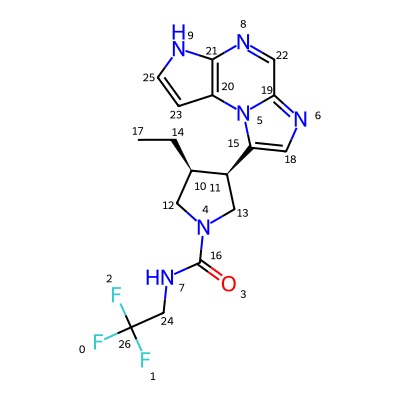

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

# Configuration for displaying in Jupyter notebooks
IPythonConsole.ipython_useSVG = True  # Use SVG for higher quality images
IPythonConsole.drawOptions.addAtomIndices = True  # Show atom indices
IPythonConsole.molSize = 400, 400 # Set size of image

ligand = Chem.MolFromMolFile("ligands/upadacitinib.sdf")
ligand

In [ ]:
# make a directory for pdb files
protein_dir = "protein_structures"
os.makedirs(protein_dir, exist_ok=True)

pdb_id = '6N7A'

pdb_request = requests.get(f"https://files.rcsb.org/download/{pdb_id}.pdb")
pdb_request.status_code